In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score
from sklearn import tree
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/Users/connorhall/datasets/inst414/module 6 assignment/Maternal Health Risk Data Set.csv')
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


### verify data 

In [5]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object

In [17]:
print(df.min(),'\n')
print(df.max(),'\n')

# find HeartRate outliers
print(df[df['HeartRate'] < 60])
# remove outliers
df = df[df['HeartRate'] > 60]

Age                   10
SystolicBP            70
DiastolicBP           49
BS                   6.0
BodyTemp            98.0
HeartRate              7
RiskLevel      high risk
dtype: object 

Age                  70
SystolicBP          160
DiastolicBP         100
BS                 19.0
BodyTemp          103.0
HeartRate            90
RiskLevel      mid risk
dtype: object 

     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate RiskLevel
499   16         120           75  7.9      98.0          7  low risk
908   16         120           75  7.9      98.0          7  low risk


### split data

In [18]:
X = df.drop(columns=['RiskLevel'])
y = df['RiskLevel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

### find optimal max_depth by plotting accuracy by depth

In [19]:
train_acc_list = []
test_acc_list = []
depths = []

for depth in range(3,12):
    clf = DecisionTreeClassifier(max_depth=depth)
    clf = clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    
    depths.append(depth)
    train_acc_list.append(round(accuracy_score(y_train, y_pred_train), 5))
    test_acc_list.append(round(accuracy_score(y_test, y_pred_test), 5))

In [27]:
print('train acc: ',train_acc_list)
print('test acc: ',test_acc_list)

train acc:  [0.66933, 0.68267, 0.72, 0.73867, 0.784, 0.82533, 0.85067, 0.87333, 0.904]
test acc:  [0.66489, 0.69149, 0.70213, 0.70745, 0.77128, 0.73404, 0.79255, 0.79255, 0.82979]


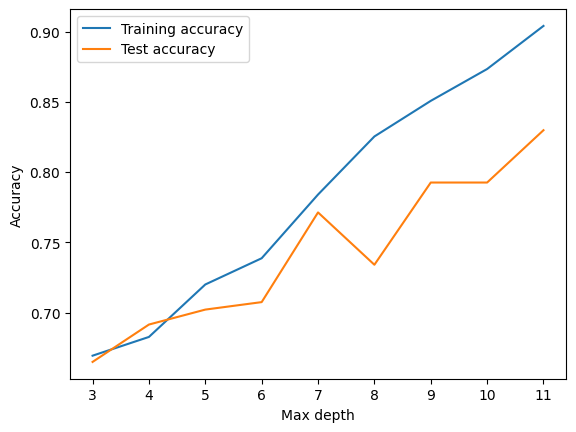

In [20]:
plt.plot(depths, train_acc_list, label='Training accuracy')
plt.plot(depths, test_acc_list, label='Test accuracy')
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### train model at max_depth = 7

In [24]:
clf = DecisionTreeClassifier(max_depth=7)
clf = clf.fit(X_train, y_train)
y_pred_test = clf.predict(X_test)

### incorrect predictions

In [25]:
compare_index = X_test[y_pred_test!=y_test].index
correct_labels = pd.DataFrame(y_test[compare_index])
incorrect_labels = pd.DataFrame(y_pred_test[y_pred_test!=y_test])\
    .set_index(compare_index).rename(columns={0: 'Predicted risk level'})
    
incorrect_pred = X_test[y_pred_test!=y_test].join(correct_labels)
incorrect_pred = incorrect_pred.join(incorrect_labels)
incorrect_pred

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,Predicted risk level
585,22,100,65,7.5,98.0,70,mid risk,low risk
79,21,90,60,6.9,98.0,86,mid risk,low risk
829,23,100,85,7.5,98.0,66,mid risk,low risk
790,12,120,90,6.8,98.0,80,mid risk,low risk
767,21,120,80,6.9,98.0,76,mid risk,low risk
89,23,100,85,6.9,98.0,66,mid risk,low risk
590,23,100,85,7.5,98.0,66,mid risk,low risk
569,23,120,80,7.5,98.0,70,mid risk,low risk
802,42,130,80,18.0,98.0,70,mid risk,high risk
969,50,130,100,16.0,98.0,75,high risk,mid risk


### visualize decision tree

In [22]:
# find correct class order
clf.classes_

array(['high risk', 'low risk', 'mid risk'], dtype=object)

[Text(0.6122448979591837, 0.9375, 'BS <= 7.95\ngini = 0.658\nsamples = 750\nvalue = [197, 296, 257]\nclass = low risk'),
 Text(0.3877551020408163, 0.8125, 'SystolicBP <= 132.5\ngini = 0.577\nsamples = 561\nvalue = [57, 290, 214]\nclass = low risk'),
 Text(0.5, 0.875, 'True  '),
 Text(0.3469387755102041, 0.6875, 'SystolicBP <= 129.5\ngini = 0.534\nsamples = 525\nvalue = [26, 290, 209]\nclass = low risk'),
 Text(0.32653061224489793, 0.5625, 'BS <= 7.055\ngini = 0.524\nsamples = 497\nvalue = [26, 290, 181]\nclass = low risk'),
 Text(0.16326530612244897, 0.4375, 'BodyTemp <= 99.5\ngini = 0.548\nsamples = 287\nvalue = [15, 132, 140]\nclass = mid risk'),
 Text(0.08163265306122448, 0.3125, 'Age <= 15.5\ngini = 0.515\nsamples = 228\nvalue = [5, 124, 99]\nclass = low risk'),
 Text(0.04081632653061224, 0.1875, 'HeartRate <= 73.0\ngini = 0.32\nsamples = 40\nvalue = [0, 32, 8]\nclass = low risk'),
 Text(0.02040816326530612, 0.0625, 'gini = 0.494\nsamples = 18\nvalue = [0, 10, 8]\nclass = low risk'

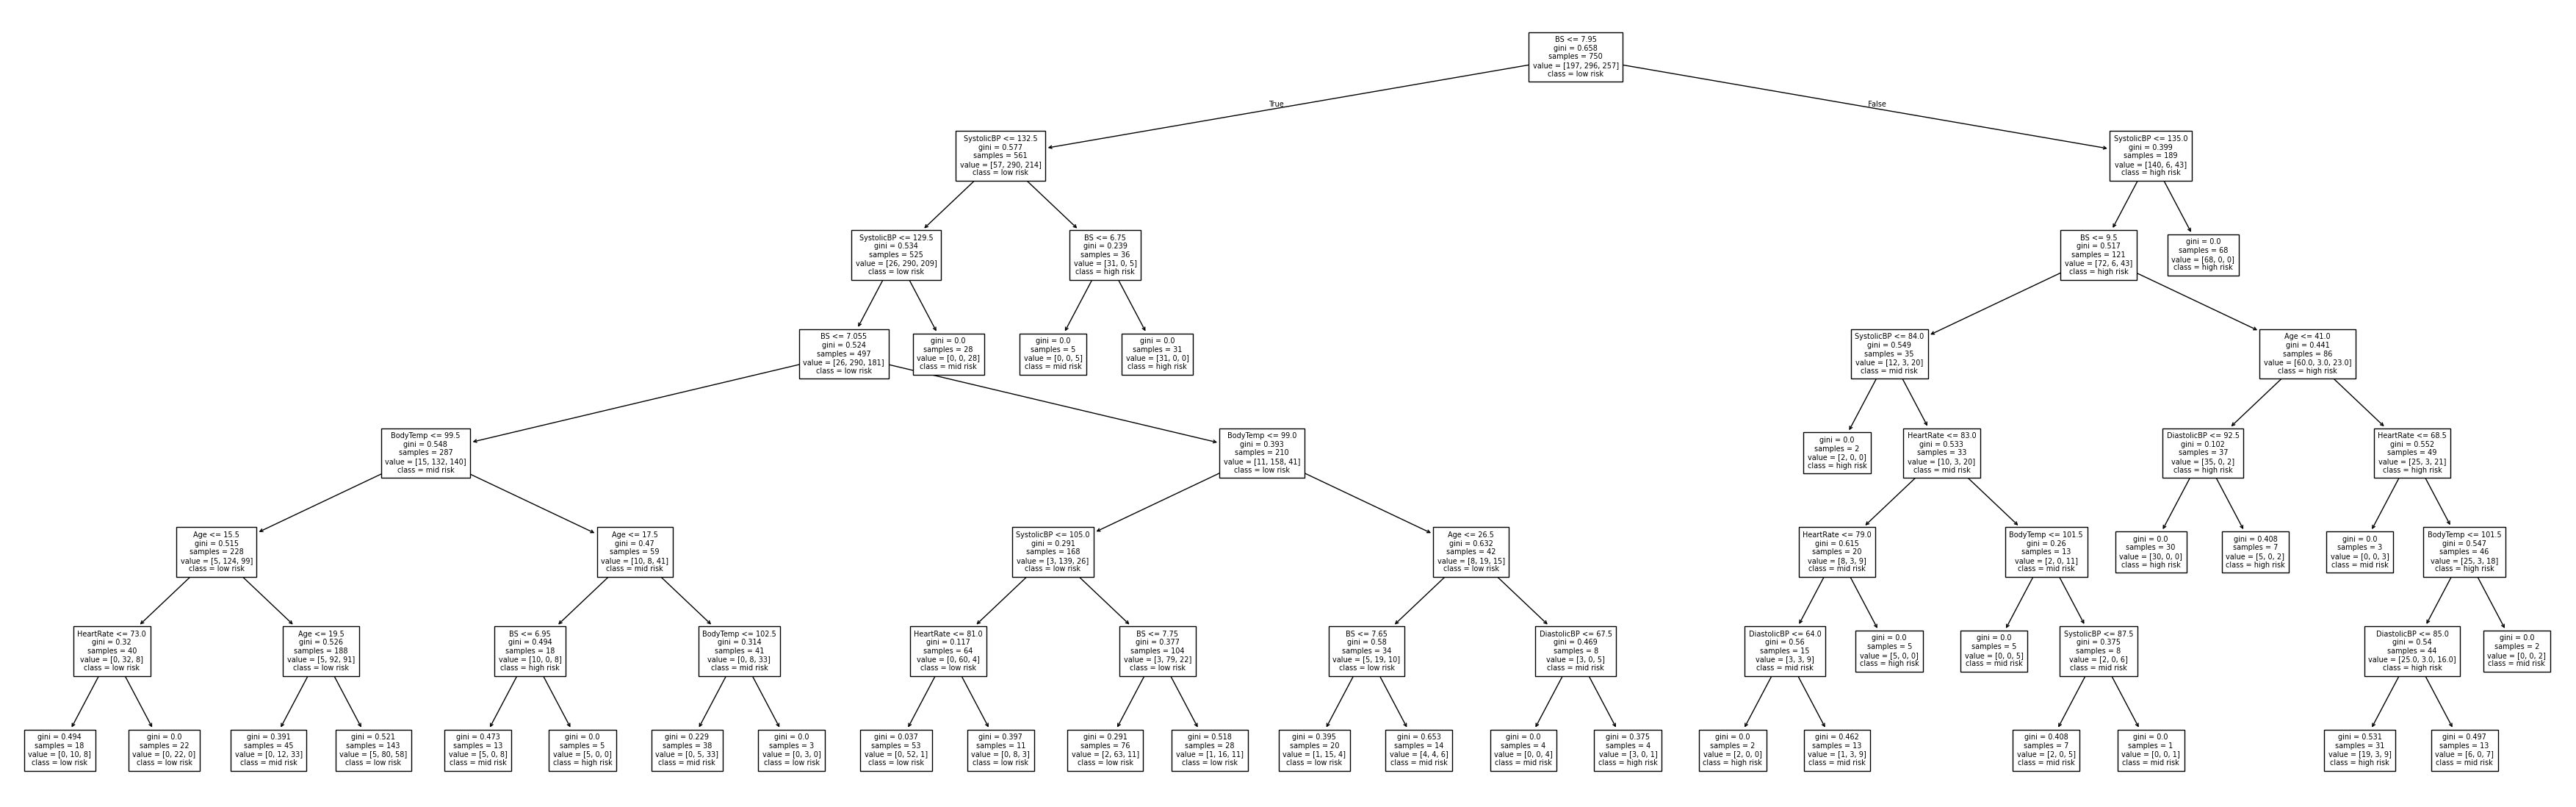

In [ ]:
plt.figure(figsize=(45,14))
features = df.drop(columns=['RiskLevel']).columns.tolist()
classes = ['high risk', 'low risk', 'mid risk']
tree.plot_tree(clf, feature_names=features, class_names=classes, fontsize=7)